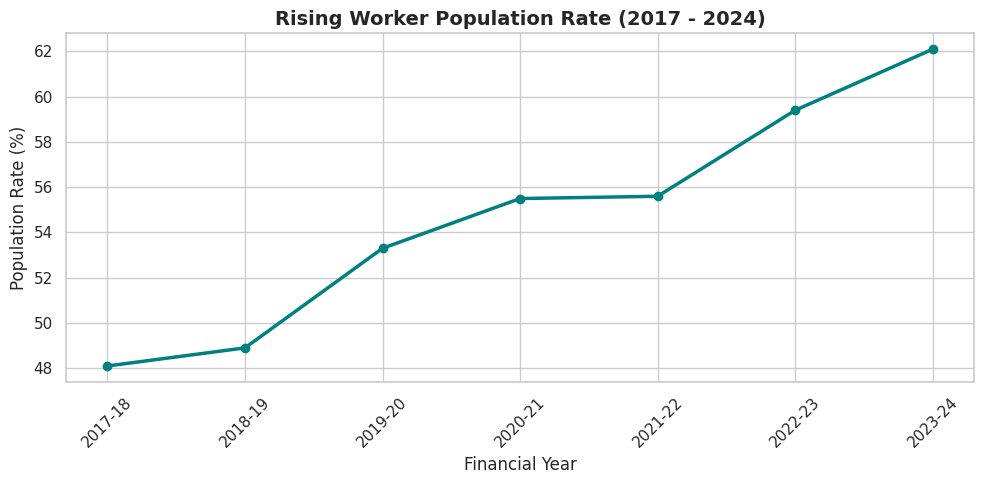

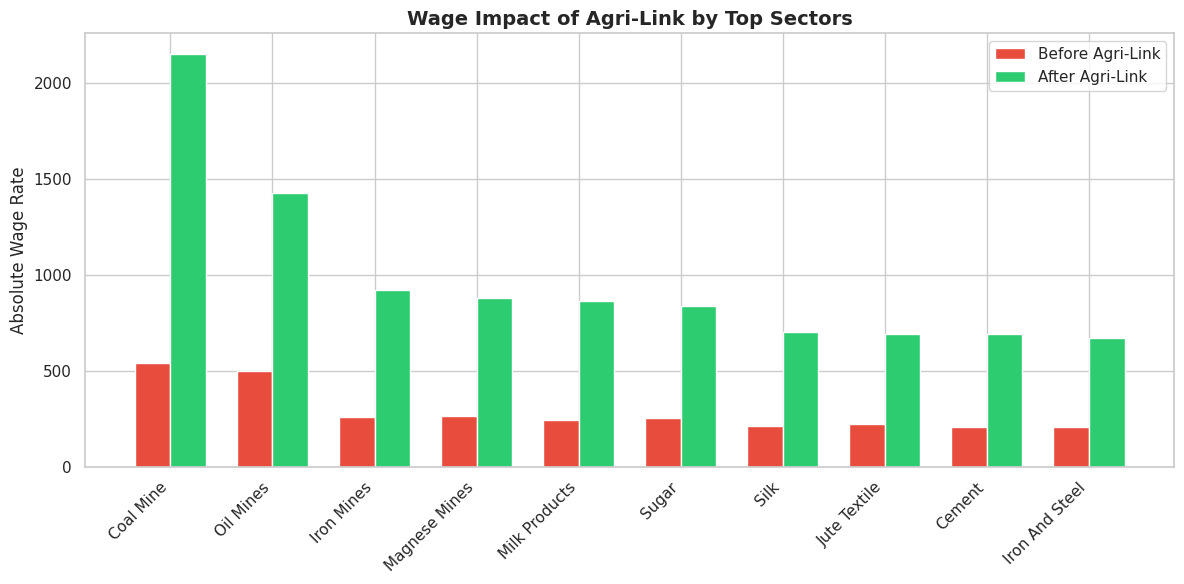

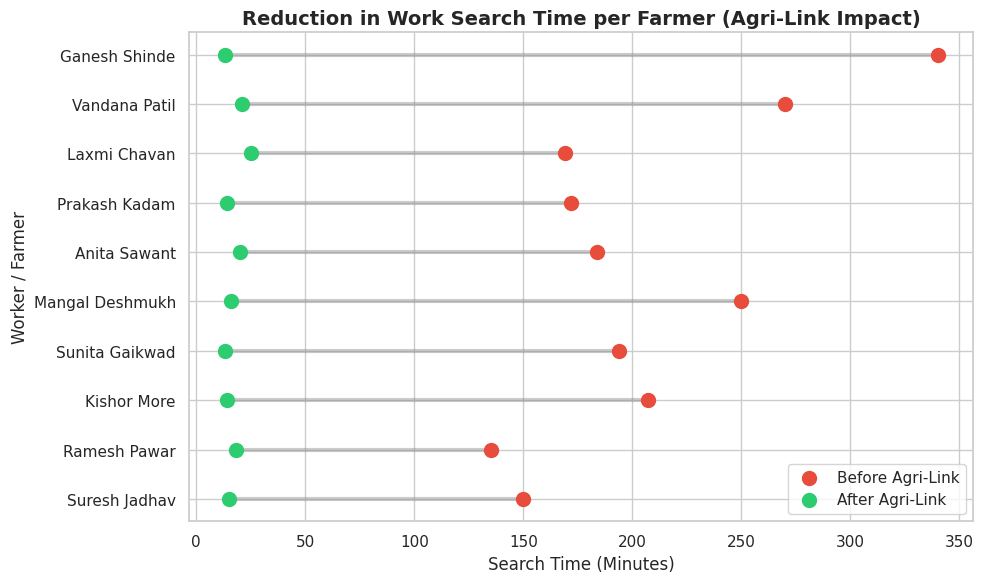

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. DATA WRANGLING & CLEANING
file_path = "/content/Data_Statistics1.xlsx"

# Using read_excel to avoid UnicodeDecodeError on .xlsx files
df_raw = pd.read_excel(file_path, header=None)

# Extract Table 1: Worker Population Rate
df_worker = df_raw.iloc[37:39, 1:9].copy()
df_worker.columns = df_worker.iloc[0]
df_worker = df_worker[1:].melt(id_vars='Months', var_name='Year', value_name='Worker Population Rate')
df_worker = df_worker.drop(columns=['Months'])
df_worker['Worker Population Rate'] = pd.to_numeric(df_worker['Worker Population Rate'])

# Extract Table 2: Agri-Link Impact Analysis (Wages)
df_impact = df_raw.iloc[161:, 2:6].dropna(how='all')
df_impact.columns = ['Commodity', 'Commission %', 'Wage Before Agri-Link', 'Wage After Agri-Link']

for col in ['Commission %', 'Wage Before Agri-Link', 'Wage After Agri-Link']:
    df_impact[col] = pd.to_numeric(df_impact[col], errors='coerce')

df_impact['Wage Growth (%)'] = ((df_impact['Wage After Agri-Link'] - df_impact['Wage Before Agri-Link']) / df_impact['Wage Before Agri-Link']) * 100
df_impact = df_impact.dropna().sort_values(by='Wage After Agri-Link', ascending=False).head(10)

# Extract Table 3: Time Taken to Search for Work (NEW - CORRECTED INDEX)
# Changed from 0:3 to 1:4 to correctly capture the non-empty columns
df_time = df_raw.iloc[101:111, 1:4].copy()
df_time.columns = ['Worker', 'Time Before (mins)', 'Time After (mins)']

# Clean up any hidden newline characters in the names (e.g. "Ramesh Pawar\n")
df_time['Worker'] = df_time['Worker'].astype(str).str.strip()

for col in ['Time Before (mins)', 'Time After (mins)']:
    df_time[col] = pd.to_numeric(df_time[col], errors='coerce')

df_time = df_time.dropna()


# 2. DATA VISUALIZATION
sns.set_theme(style="whitegrid", palette="muted")

# Chart A: Worker Population Rate Trend
plt.figure(figsize=(10, 5))
plt.plot(df_worker['Year'], df_worker['Worker Population Rate'], marker='o', color='teal', linewidth=2.5)
plt.title('Rising Worker Population Rate (2017 - 2024)', fontsize=14, fontweight='bold')
plt.xlabel('Financial Year')
plt.ylabel('Population Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Chart B: Before vs After Agri-Link Wage Comparison
plt.figure(figsize=(12, 6))
index = np.arange(len(df_impact))
bar_width = 0.35

plt.bar(index, df_impact['Wage Before Agri-Link'], bar_width, label='Before Agri-Link', color='#e74c3c')
plt.bar(index + bar_width, df_impact['Wage After Agri-Link'], bar_width, label='After Agri-Link', color='#2ecc71')

plt.title('Wage Impact of Agri-Link by Top Sectors', fontsize=14, fontweight='bold')
plt.xticks(index + bar_width / 2, df_impact['Commodity'].str.title(), rotation=45, ha='right')
plt.ylabel('Absolute Wage Rate')
plt.legend()
plt.tight_layout()
plt.show()

# NEW Chart C: Time Saved (Dumbbell Plot)
plt.figure(figsize=(10, 6))

# Draw lines connecting the before and after points
plt.hlines(y=df_time['Worker'], xmin=df_time['Time After (mins)'], xmax=df_time['Time Before (mins)'], color='grey', alpha=0.4, linewidth=3)

# Draw the points
plt.scatter(df_time['Time Before (mins)'], df_time['Worker'], color='#e74c3c', s=100, label='Before Agri-Link', zorder=3)
plt.scatter(df_time['Time After (mins)'], df_time['Worker'], color='#2ecc71', s=100, label='After Agri-Link', zorder=3)

plt.title('Reduction in Work Search Time per Farmer (Agri-Link Impact)', fontsize=14, fontweight='bold')
plt.xlabel('Search Time (Minutes)')
plt.ylabel('Worker / Farmer')
plt.legend()
plt.tight_layout()
plt.show()